# Bank Loan Applications — Data Cleaning & Visualization

**Objective:** Clean a realistic, slightly dirty bank loan applications dataset (25,000 rows), perform feature engineering, and visualize key distributions and relationships. This notebook is beginner→intermediate friendly (mix of explanations + concise code).

### Importing Libriaries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Loading the Data Set

In [55]:
df = pd.read_csv(r"D:\My Courses\1. Learnbay\1. My Projects\10. Bank Loan Applications (Python)\bank_loan_applications_25000_dirty.csv", low_memory=False)

# Converting date column
df["Application_Date"] = pd.to_datetime(df["Application_Date"], errors="coerce")

df.head()

,Application_ID,Gender,Age,Education,Marital_Status,Employment_Type,Monthly_Income,Loan_Amount,Loan_Term,Credit_Score,Existing_Debt,Approval_Status,Application_Date
0,APP100000,male,50.0,GRADUATE,SINGLE,Salaried,56871,1900823,12.0,603.0,570221.0,Rejected,2022-12-21
1,APP100001,MALE,39.0,Not Graduate,Married,Salaried,11176,"1,916,690",48.0,999.0,141511.0,Rejected,2022-05-11
2,APP100002,FEMALE,53.0,Not Graduate,MARRIED,SALARIED,39869,"512,547",24.0,746.0,679685.0,Approved,2019-08-27
3,APP100003,NaN,40.0,graduate,Single,Salaried,93181,1918013,72.0,330.0,739322.0,Rejected,2022-01-19
4,APP100004,MALE,80.0,graduate,Single,SALARIED,85737,2214169,24.0,619.0,233673.0,Approved,2019-12-02


### Basic DataSet Information

In [56]:
df.shape

(25000, 13)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Application_ID    24250 non-null  object        
 1   Gender            24250 non-null  object        
 2   Age               24250 non-null  float64       
 3   Education         24250 non-null  object        
 4   Marital_Status    24250 non-null  object        
 5   Employment_Type   24250 non-null  object        
 6   Monthly_Income    24250 non-null  object        
 7   Loan_Amount       24250 non-null  object        
 8   Loan_Term         24250 non-null  float64       
 9   Credit_Score      24250 non-null  float64       
 10  Existing_Debt     24250 non-null  float64       
 11  Approval_Status   24250 non-null  object        
 12  Application_Date  24250 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(4), object(8)
memory usage: 2.5+ MB


In [58]:
df.describe()

,Age,Loan_Term,Credit_Score,Existing_Debt,Application_Date
count,24250.000000,24250.000000,24250.000000,24250.000000,24250
mean,53.834186,41.933691,596.068082,496410.156948,2021-06-25 10:17:05.517525504
min,-5.000000,12.000000,-50.000000,126.000000,2018-01-01 00:00:00
25%,35.000000,24.000000,446.000000,240967.250000,2019-09-29 00:00:00
50%,53.000000,36.000000,594.000000,496944.000000,2021-06-26 00:00:00
75%,72.000000,60.000000,746.000000,744599.250000,2023-03-20 00:00:00
max,150.000000,72.000000,999.000000,999932.000000,2024-12-31 00:00:00
std,24.223124,20.536093,174.891889,289768.210409,NaN


### Checking Missing Values

In [61]:
df.isnull().sum()

Application_ID      750
Gender              750
Age                 750
Education           750
Marital_Status      750
Employment_Type     750
Monthly_Income      750
Loan_Amount         750
Loan_Term           750
Credit_Score        750
Existing_Debt       750
Approval_Status     750
Application_Date    750
dtype: int64

### Cleaning Categorical Columns

### Gender

In [63]:
df["Gender"] = df["Gender"].astype(str).str.strip().str.lower()

df["Gender"] = df["Gender"].replace({
    "male": "Male",
    "female": "Female"
})

df.loc[df["Gender"] == "nan", "Gender"] = np.nan

### Education

In [64]:
df["Education"] = df["Education"].astype(str).str.strip().str.lower()

df["Education"] = df["Education"].replace({
    "graduate": "Graduate",
    "not graduate": "Not Graduate"
})

df.loc[df["Education"] == "nan", "Education"] = np.nan

### Marital Status

In [65]:
df["Marital_Status"] = df["Marital_Status"].astype(str).str.strip().str.lower()

df["Marital_Status"] = df["Marital_Status"].replace({
    "married": "Married",
    "single": "Single"
})

df.loc[df["Marital_Status"] == "nan", "Marital_Status"] = np.nan

### Employment Type

In [66]:
df["Employment_Type"] = df["Employment_Type"].astype(str).str.strip().str.lower()

df["Employment_Type"] = df["Employment_Type"].replace({
    "salaried": "Salaried",
    "self-employed": "Self-Employed",
    "self employed": "Self-Employed"
})

df.loc[df["Employment_Type"] == "nan", "Employment_Type"] = np.nan

### Approval Status

In [67]:
df["Approval_Status"] = df["Approval_Status"].astype(str).str.strip().str.title()

df.loc[df["Approval_Status"] == "Nan", "Approval_Status"] = np.nan

### Removing Commas

In [68]:
df["Monthly_Income"] = df["Monthly_Income"].astype(str).str.replace(",", "")
df["Loan_Amount"] = df["Loan_Amount"].astype(str).str.replace(",", "")
df["Existing_Debt"] = df["Existing_Debt"].astype(str).str.replace(",", "")

### Converting to Numeric

In [69]:
df["Monthly_Income"] = pd.to_numeric(df["Monthly_Income"], errors="coerce")
df["Loan_Amount"] = pd.to_numeric(df["Loan_Amount"], errors="coerce")
df["Existing_Debt"] = pd.to_numeric(df["Existing_Debt"], errors="coerce")
df["Loan_Term"] = pd.to_numeric(df["Loan_Term"], errors="coerce")
df["Credit_Score"] = pd.to_numeric(df["Credit_Score"], errors="coerce")
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

### Cleaning Age

In [70]:
df.loc[df["Age"] < 18, "Age"] = np.nan
df.loc[df["Age"] > 100, "Age"] = np.nan

### Cleaning Credit Score

In [71]:
df.loc[df["Credit_Score"] < 300, "Credit_Score"] = np.nan
df.loc[df["Credit_Score"] > 850, "Credit_Score"] = np.nan

### Filling Missing Values in Numeric Columns

In [72]:
num_cols = ["Monthly_Income", "Loan_Amount", "Existing_Debt", "Age", "Loan_Term", "Credit_Score"]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

### Filling Missing Values in Categorical Columns

In [73]:
cat_cols = ["Gender", "Education", "Marital_Status", "Employment_Type", "Approval_Status"]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

### Calculaion of EMI Using Feature Engineering

In [74]:
monthly_rate = 0.10 / 12

P = df["Loan_Amount"]
n = df["Loan_Term"]

df["EMI"] = P * monthly_rate / (1 - (1 + monthly_rate) ** (-n))

### Final Cleaning Check

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Application_ID    24250 non-null  object        
 1   Gender            25000 non-null  object        
 2   Age               25000 non-null  float64       
 3   Education         25000 non-null  object        
 4   Marital_Status    25000 non-null  object        
 5   Employment_Type   25000 non-null  object        
 6   Monthly_Income    25000 non-null  float64       
 7   Loan_Amount       25000 non-null  float64       
 8   Loan_Term         25000 non-null  float64       
 9   Credit_Score      25000 non-null  float64       
 10  Existing_Debt     25000 non-null  float64       
 11  Approval_Status   25000 non-null  object        
 12  Application_Date  24250 non-null  datetime64[ns]
 13  EMI               25000 non-null  float64       
dtypes: datetime64[ns](1), 

In [76]:
df.isnull().sum()

Application_ID      750
Gender                0
Age                   0
Education             0
Marital_Status        0
Employment_Type       0
Monthly_Income        0
Loan_Amount           0
Loan_Term             0
Credit_Score          0
Existing_Debt         0
Approval_Status       0
Application_Date    750
EMI                   0
dtype: int64

In [77]:
df.head()

,Application_ID,Gender,Age,Education,Marital_Status,Employment_Type,Monthly_Income,Loan_Amount,Loan_Term,Credit_Score,Existing_Debt,Approval_Status,Application_Date,EMI
0,APP100000,Male,50.0,Graduate,Single,Salaried,56871.0,1900823.0,12.0,603.0,570221.0,Rejected,2022-12-21,167112.540512
1,APP100001,Male,39.0,Not Graduate,Married,Salaried,11176.0,1916690.0,48.0,570.0,141511.0,Rejected,2022-05-11,48612.210044
2,APP100002,Female,53.0,Not Graduate,Married,Salaried,39869.0,512547.0,24.0,746.0,679685.0,Approved,2019-08-27,23651.443560
3,APP100003,Male,40.0,Graduate,Single,Salaried,93181.0,1918013.0,72.0,330.0,739322.0,Rejected,2022-01-19,35532.797690
4,APP100004,Male,80.0,Graduate,Single,Salaried,85737.0,2214169.0,24.0,619.0,233673.0,Approved,2019-12-02,102172.665404


### Filling Missing Id's

In [78]:
# Fix Application_ID (replace missing values)
missing_ids = df["Application_ID"].isnull()

df.loc[missing_ids, "Application_ID"] = [
    f"APP_MISSING_{i}" for i in range(1, missing_ids.sum() + 1)
]

### Filling Missing Dates

In [79]:
median_date = df["Application_Date"].median()

df["Application_Date"] = df["Application_Date"].fillna(median_date)

In [80]:
df["Application_ID"].isnull().sum(), df["Application_Date"].isnull().sum()

(0, 0)

In [81]:
df.isnull().sum()

Application_ID      0
Gender              0
Age                 0
Education           0
Marital_Status      0
Employment_Type     0
Monthly_Income      0
Loan_Amount         0
Loan_Term           0
Credit_Score        0
Existing_Debt       0
Approval_Status     0
Application_Date    0
EMI                 0
dtype: int64

### Visualisation

### Monthly Income Distribution

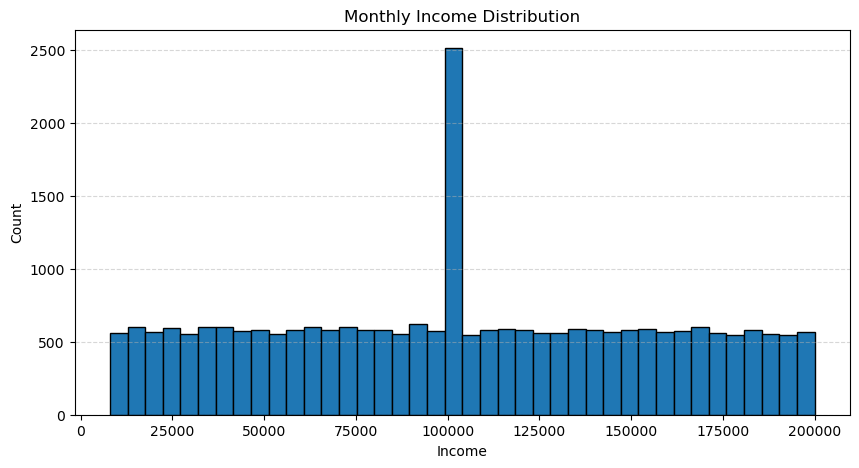

In [82]:
plt.figure(figsize=(10,5))
plt.hist(df["Monthly_Income"], bins=40, edgecolor="black")
plt.title("Monthly Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

### Loan Amount Distribution

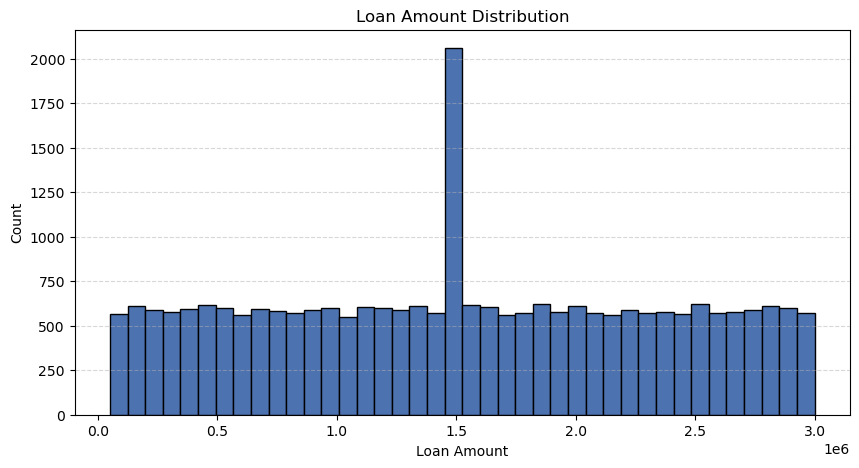

In [83]:
plt.figure(figsize=(10,5))
plt.hist(df["Loan_Amount"], bins=40, edgecolor="black", color="#4C72B0")
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

### Credit Score Box Plot

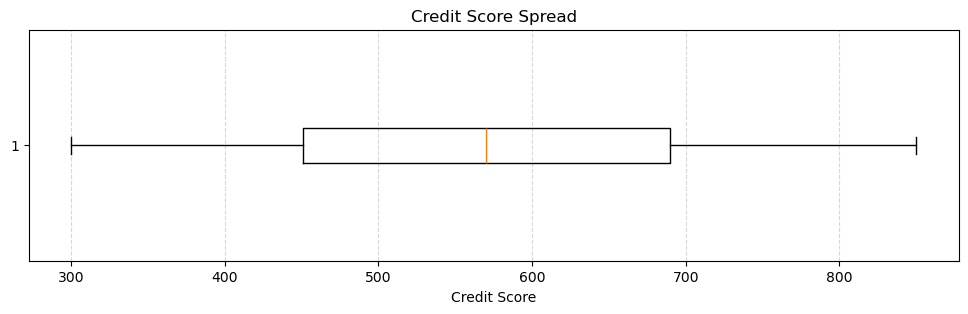

In [84]:
plt.figure(figsize=(12,3))
plt.boxplot(df["Credit_Score"], vert=False)
plt.title("Credit Score Spread")
plt.xlabel("Credit Score")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

### Loan Approval Count

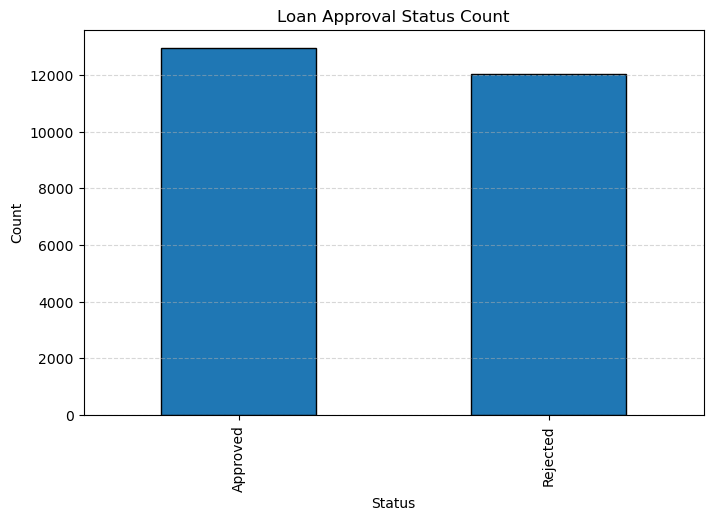

In [85]:
df["Approval_Status"].value_counts().plot(kind="bar", figsize=(8,5), edgecolor="black")
plt.title("Loan Approval Status Count")
plt.xlabel("Status")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

### Approval Rate by Employment Type

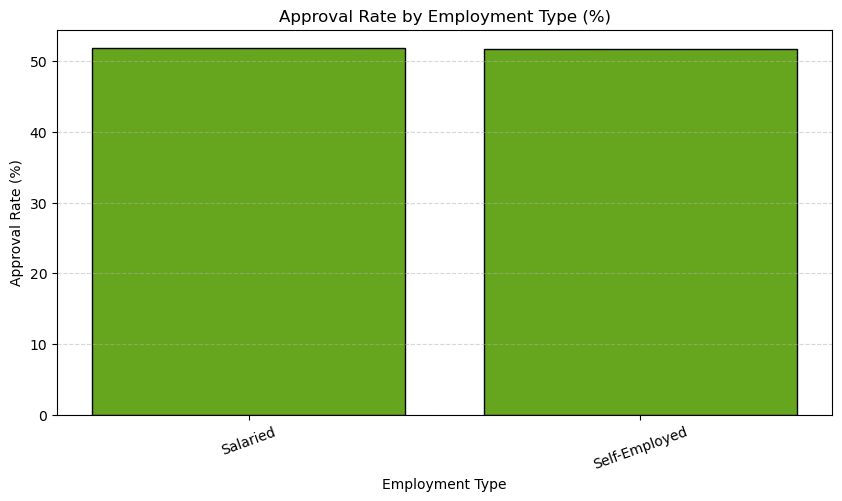

In [86]:
temp = df.groupby("Employment_Type")["Approval_Status"].value_counts().unstack()

approval_rate = (temp["Approved"] / temp.sum(axis=1)) * 100

plt.figure(figsize=(10,5))
plt.bar(approval_rate.index, approval_rate.values, edgecolor="black", color="#66A61E")
plt.title("Approval Rate by Employment Type (%)")
plt.xlabel("Employment Type")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [88]:
df.to_csv("bank_loan_cleaned_FINAL.csv", index=False)
print("File saved successfully!")

File saved successfully!
